# Linking to parent datasets

When performing a measurement in QCoDeS, it is possible to annotate the outcome (the dataset) of that measurement as having one or more parent datasets. This is done by adding a link to each parent dataset. This notebook covers the mechanisms to do that by going through a few practical examples.

In [1]:
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt

from qcodes.dataset import (
    Measurement,
    initialise_or_create_database_at,
    load_by_run_spec,
    load_or_create_experiment,
    plot_dataset,
)

In [2]:
now = str(datetime.datetime.now())
tutorial_db_path = Path.cwd().parent / "example_output" / "linking_datasets_tutorial.db"
initialise_or_create_database_at(tutorial_db_path)
load_or_create_experiment("tutorial " + now, "no sample")

tutorial 2025-06-27 08:52:17.049719#no sample#1@/home/runner/work/Qcodes/Qcodes/docs/examples/example_output/linking_datasets_tutorial.db
-----------------------------------------------------------------------------------------------------------------------------------------

## Example 1: Measuring and then fitting

Say we measure some raw data and subsequently do a curve fit to those data. We'd like to save the fit as a separate dataset that has a link to the dataset of the original data. This is achieved in two steps.

### Step 1: measure raw data

In [3]:
meas = Measurement()
meas.register_custom_parameter(name="time", label="Time", unit="s", paramtype="array")
meas.register_custom_parameter(
    name="signal", label="Signal", unit="V", paramtype="array", setpoints=["time"]
)

N = 500

with meas.run() as datasaver:
    time_data = np.linspace(0, 1, N)
    signal_data = np.sin(2 * np.pi * time_data) + 0.25 * np.random.randn(N)

    datasaver.add_result(("time", time_data), ("signal", signal_data))
dataset = datasaver.dataset

Starting experimental run with id: 1. 


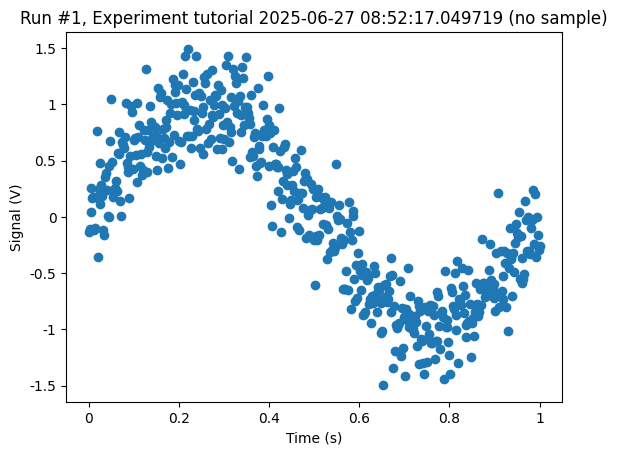

In [4]:
cbs, axs = plot_dataset(dataset)

### Step 2: Set up a fit "measurement"

We now load the raw data dataset, set up a new measurement for the fit, register the raw data as a parent and save a fit.

As the very first step, we supply a model to fit to.

In [5]:
def fit_func(x, a, b):
    return a * np.sin(2 * np.pi * x) + b

Next, we set up the fitting measurement.

In [6]:
raw_data = load_by_run_spec(captured_run_id=dataset.captured_run_id)

meas = Measurement()
meas.register_custom_parameter(
    "fit_axis", label="Fit axis", unit="t", paramtype="array"
)
meas.register_custom_parameter(
    "fit_curve",
    label="Fitted curve",
    unit="V",
    paramtype="array",
    setpoints=["fit_axis"],
)
meas.register_custom_parameter(
    "fit_param_a", label="Fitted parameter amplitude", unit="V"
)
meas.register_custom_parameter("fit_param_b", label="Fitted parameter offset", unit="V")
meas.register_parent(parent=raw_data, link_type="curve fit")

As we now run the measurement, the parent datasets become available via the datasaver. The datasets appear in the order they were registered.

In [7]:
with meas.run() as datasaver:
    raw = datasaver.parent_datasets[0]
    xdata = np.ravel(raw.get_parameter_data()["signal"]["time"])
    ydata = np.ravel(raw.get_parameter_data()["signal"]["signal"])

    popt, pcov = opt.curve_fit(fit_func, xdata, ydata, p0=[1, 1])

    fit_axis = xdata
    fit_curve = fit_func(fit_axis, *popt)

    datasaver.add_result(
        ("fit_axis", fit_axis),
        ("fit_curve", fit_curve),
        ("fit_param_a", popt[0]),
        ("fit_param_b", popt[1]),
    )

fit_data = datasaver.dataset

Starting experimental run with id: 2. 


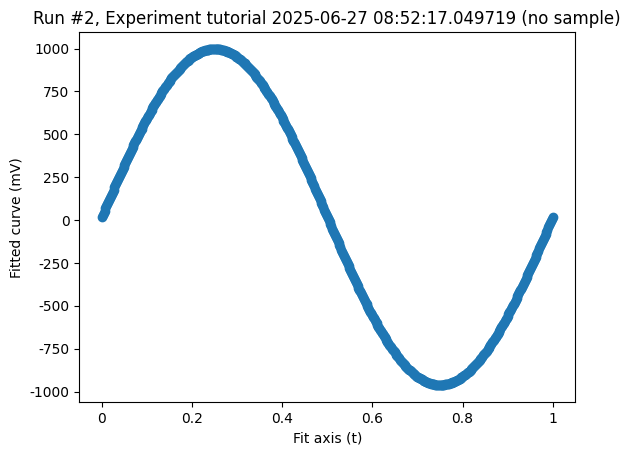

In [8]:
cbs, axs = plot_dataset(fit_data)

And just for completeness, let us plot both datasets on top of each other.

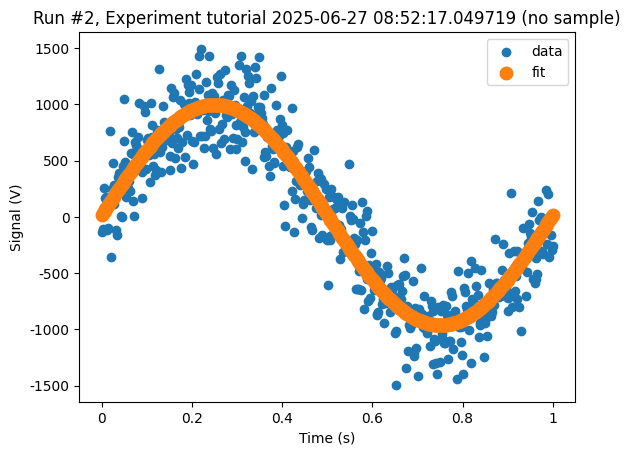

In [9]:
fig, ax = plt.subplots(1)
cbs, axs = plot_dataset(raw_data, axes=ax, label="data")
cbs, axs = plot_dataset(fit_data, axes=ax, label="fit", linewidth=4)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Signal (V)")
plt.legend()